In [1]:
# ============================================
# CELL 1: SETUP - HISTOIRE-GEO BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("=" * 60)
print("📜 HISTOIRE-GEOGRAPHIE BAC PREDICTOR")
print("=" * 60)
print("✅ Libraries loaded")
print("🎯 Target: BAC Score /20")
print("⏱️ Duration: 3h30")
print("📚 Exam: History (10pts) + Geography (10pts)")
print("🔥 Keys: MEMORY + METHODOLOGY (not practice!)")
print("😌 Stress impact: VERY LOW (~0.08)")
print("=" * 60)
print("\n✅ Cell 1 complete")

📜 HISTOIRE-GEOGRAPHIE BAC PREDICTOR
✅ Libraries loaded
🎯 Target: BAC Score /20
⏱️ Duration: 3h30
📚 Exam: History (10pts) + Geography (10pts)
🔥 Keys: MEMORY + METHODOLOGY (not practice!)
😌 Stress impact: VERY LOW (~0.08)

✅ Cell 1 complete


In [2]:
# ============================================
# CELL 2: DATASET GENERATION - HISTOIRE-GEO
# Memory + Methodology focused (not practice!)
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("GENERATING HISTOIRE-GEO DATASET")
print("Target: Mean ~13.2 | Fail ~10% | Excellent ~15%")
print("Keys: MEMORY (40%) + METHODOLOGY (40%) + Knowledge (20%)")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution
# ============================================

bac_scores = []
n_fail = int(n_students * 0.10)
failing = np.random.uniform(6, 9.9, n_fail)
bac_scores.extend(failing)

n_excellent = int(n_students * 0.15)
excellent = np.random.uniform(17, 20, n_excellent)
bac_scores.extend(excellent)

n_avg = n_students - n_fail - n_excellent
average = np.random.normal(13.5, 1.5, n_avg)
average = np.clip(average, 10, 16.9)
bac_scores.extend(average)

bac_scores = np.array(bac_scores)
np.random.shuffle(bac_scores)
bac_scores = np.round(bac_scores, 1)

bac_mean = bac_scores.mean()
bac_std = bac_scores.std()
bac_scaled = (bac_scores - bac_mean) / bac_std

print(f"\n📊 BAC Score Distribution:")
print(f"   Mean: {bac_mean:.2f}")
print(f"   Std: {bac_std:.2f}")
print(f"   Fail (<10): {(bac_scores < 10).sum()} ({(bac_scores < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent (17-20): {(bac_scores >= 17).sum()} ({(bac_scores >= 17).sum()/n_students*100:.1f}%)")

# Helper function
def generate_feature(bac_scaled, target_corr, target_mean, target_std):
    signal = target_corr * bac_scaled * target_std
    noise_std = target_std * np.sqrt(max(0.01, 1 - target_corr**2))
    noise = np.random.normal(0, noise_std, n_students)
    feature = target_mean + signal + noise
    return feature

# ============================================
# A. ACADEMIC HISTORY (5 features)
# ============================================

avg_grade = generate_feature(bac_scaled, 0.65, 13.0, 2.2)
avg_grade = np.clip(avg_grade, 8, 19.5).round(1)

grade_t3 = avg_grade + np.random.normal(0.3, 0.8, n_students)
grade_t3 = np.clip(grade_t3, 8, 19.5).round(1)

grade_t2 = avg_grade + np.random.normal(0, 0.9, n_students)
grade_t2 = np.clip(grade_t2, 8, 19.5).round(1)

grade_t1 = avg_grade - np.random.normal(0.5, 1.0, n_students)
grade_t1 = np.clip(grade_t1, 8, 19.5).round(1)

grade_trend = (grade_t3 - grade_t1).round(1)

print(f"\n✅ A. Academic History (5 features)")

# ============================================
# B. MEMORY SKILLS (MOST IMPORTANT - 40% of success)
# ============================================

# Historical facts memory (dates, events, causes, consequences)
historical_memory = generate_feature(bac_scaled, 0.55, 6.5, 1.5)
historical_memory = np.clip(historical_memory, 2, 10).round(1)

# Dates memory (key dates)
dates_memory = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
dates_memory = np.clip(dates_memory, 2, 10).round(1)

# Figures/Personalities memory
figures_memory = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
figures_memory = np.clip(figures_memory, 2, 10).round(1)

# Geographical knowledge
geography_knowledge = generate_feature(bac_scaled, 0.50, 6.3, 1.6)
geography_knowledge = np.clip(geography_knowledge, 2, 10).round(1)

print(f"✅ B. Memory Skills (4 features) - CRITICAL!")

# ============================================
# C. METHODOLOGY SKILLS (MOST IMPORTANT - 40% of success)
# ============================================

# Document analysis method (texts, maps, statistics)
document_analysis_method = generate_feature(bac_scaled, 0.60, 6.5, 1.5)
document_analysis_method = np.clip(document_analysis_method, 2, 10).round(1)

# Essay structure method (Intro → Development → Conclusion)
essay_method = generate_feature(bac_scaled, 0.60, 6.5, 1.5)
essay_method = np.clip(essay_method, 2, 10).round(1)

# Map/Statistics interpretation
map_stats_method = generate_feature(bac_scaled, 0.55, 6.2, 1.6)
map_stats_method = np.clip(map_stats_method, 2, 10).round(1)

# Argumentation quality
argumentation_skill = generate_feature(bac_scaled, 0.55, 6.2, 1.6)
argumentation_skill = np.clip(argumentation_skill, 2, 10).round(1)

print(f"✅ C. Methodology Skills (4 features) - CRITICAL!")

# ============================================
# D. KNOWLEDGE SCORES (20% of success)
# ============================================

# History specific topics
cold_war_knowledge = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
cold_war_knowledge = np.clip(cold_war_knowledge, 2, 10).round(1)

decolonization_knowledge = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
decolonization_knowledge = np.clip(decolonization_knowledge, 2, 10).round(1)

algeria_history_knowledge = generate_feature(bac_scaled, 0.50, 6.3, 1.6)
algeria_history_knowledge = np.clip(algeria_history_knowledge, 2, 10).round(1)

# Geography specific topics
economic_powers_knowledge = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
economic_powers_knowledge = np.clip(economic_powers_knowledge, 2, 10).round(1)

development_knowledge = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
development_knowledge = np.clip(development_knowledge, 2, 10).round(1)

print(f"✅ D. Knowledge Scores (5 features)")

# ============================================
# E. EXAM STRUCTURE UNDERSTANDING
# ============================================

history_part_structure = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
history_part_structure = np.clip(history_part_structure, 2, 10).round(1)

geography_part_structure = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
geography_part_structure = np.clip(geography_part_structure, 2, 10).round(1)

print(f"✅ E. Exam Structure (2 features)")

# ============================================
# F. PRACTICE (LOW impact - just for familiarity)
# ============================================

bac_exams_practiced = generate_feature(bac_scaled, 0.25, 5, 4)
bac_exams_practiced = np.clip(bac_exams_practiced, 0, 15).round(0).astype(int)

print(f"✅ F. Practice (1 feature - LOW impact)")

# ============================================
# G. STUDY BEHAVIOR
# ============================================

memorization_frequency = generate_feature(bac_scaled, 0.40, 6, 2)
memorization_frequency = np.clip(memorization_frequency, 1, 10).round(1)

study_hours = generate_feature(bac_scaled, 0.20, 4, 2)
study_hours = np.clip(study_hours, 2, 10).round(1)

consistency = generate_feature(bac_scaled, 0.25, 6, 2)
consistency = np.clip(consistency, 1, 10).round(1)

print(f"✅ G. Study Behavior (3 features)")

# ============================================
# H. PSYCHOLOGICAL (VERY LOW impact - not stressful)
# ============================================

stress_level = generate_feature(bac_scaled, -0.08, 5.0, 2.0)
stress_level = np.clip(stress_level, 1, 10).round(1)

confidence_level = generate_feature(bac_scaled, 0.15, 6.0, 1.8)
confidence_level = np.clip(confidence_level, 1, 10).round(1)

interest_in_subject = generate_feature(bac_scaled, 0.20, 6.0, 1.8)
interest_in_subject = np.clip(interest_in_subject, 1, 10).round(1)

print(f"✅ H. Psychological (3 features - VERY LOW stress impact)")

# ============================================
# CREATE FINAL DATAFRAME
# ============================================

df = pd.DataFrame({
    # A. Academic History
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': grade_trend,
    
    # B. Memory Skills (CRITICAL)
    'historical_memory': historical_memory,
    'dates_memory': dates_memory,
    'figures_memory': figures_memory,
    'geography_knowledge': geography_knowledge,
    
    # C. Methodology Skills (CRITICAL)
    'document_analysis_method': document_analysis_method,
    'essay_method': essay_method,
    'map_stats_method': map_stats_method,
    'argumentation_skill': argumentation_skill,
    
    # D. Knowledge Scores
    'cold_war_knowledge': cold_war_knowledge,
    'decolonization_knowledge': decolonization_knowledge,
    'algeria_history_knowledge': algeria_history_knowledge,
    'economic_powers_knowledge': economic_powers_knowledge,
    'development_knowledge': development_knowledge,
    
    # E. Exam Structure
    'history_part_structure': history_part_structure,
    'geography_part_structure': geography_part_structure,
    
    # F. Practice (LOW impact)
    'bac_exams_practiced': bac_exams_practiced,
    
    # G. Study Behavior
    'memorization_frequency': memorization_frequency,
    'study_hours': study_hours,
    'consistency': consistency,
    
    # H. Psychological (VERY LOW)
    'stress_level': stress_level,
    'confidence_level': confidence_level,
    'interest_in_subject': interest_in_subject,
    
    # TARGET
    'bac_score_hg': bac_scores
})

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Students: {len(df)}")
print(f"   Features: {len(df.columns) - 1}")
print(f"   Target: bac_score_hg")

# Verification
print("\n📊 VERIFICATION - ACTUAL CORRELATIONS:")
print("-" * 50)

key_features = [
    ('avg_grade', 0.65),
    ('document_analysis_method', 0.60),
    ('essay_method', 0.60),
    ('historical_memory', 0.55),
    ('argumentation_skill', 0.55),
    ('geography_knowledge', 0.50),
    ('algeria_history_knowledge', 0.50),
    ('dates_memory', 0.45),
    ('bac_exams_practiced', 0.25),
    ('stress_level', -0.08),
]

for feature, target in key_features:
    if feature in df.columns:
        actual = np.corrcoef(df['bac_score_hg'], df[feature])[0,1]
        status = "✅" if abs(actual - target) < 0.08 else "⚠️"
        print(f"   {feature:<30} actual: {actual:>6.3f} target: {target:>5.2f} {status}")

print("\n📊 FINAL DISTRIBUTION:")
print(f"   Mean: {df['bac_score_hg'].mean():.2f}/20")
print(f"   Fail: {(df['bac_score_hg'] < 10).sum()} ({(df['bac_score_hg'] < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent: {(df['bac_score_hg'] >= 17).sum()} ({(df['bac_score_hg'] >= 17).sum()/n_students*100:.1f}%)")

print("\n📊 First 5 rows:")
print(df[['bac_score_hg', 'historical_memory', 'document_analysis_method', 'essay_method']].head())

print("\n" + "=" * 60)
print("✅ Cell 2 complete! Ready for Cell 3")
print("=" * 60)

GENERATING HISTOIRE-GEO DATASET
Target: Mean ~13.2 | Fail ~10% | Excellent ~15%
Keys: MEMORY (40%) + METHODOLOGY (40%) + Knowledge (20%)

📊 BAC Score Distribution:
   Mean: 13.79
   Std: 2.98
   Fail (<10): 50 (10.0%)
   Excellent (17-20): 75 (15.0%)

✅ A. Academic History (5 features)
✅ B. Memory Skills (4 features) - CRITICAL!
✅ C. Methodology Skills (4 features) - CRITICAL!
✅ D. Knowledge Scores (5 features)
✅ E. Exam Structure (2 features)
✅ F. Practice (1 feature - LOW impact)
✅ G. Study Behavior (3 features)
✅ H. Psychological (3 features - VERY LOW stress impact)

✅ FINAL DATASET GENERATED
   Students: 500
   Features: 27
   Target: bac_score_hg

📊 VERIFICATION - ACTUAL CORRELATIONS:
--------------------------------------------------
   avg_grade                      actual:  0.675 target:  0.65 ✅
   document_analysis_method       actual:  0.604 target:  0.60 ✅
   essay_method                   actual:  0.611 target:  0.60 ✅
   historical_memory              actual:  0.527 targe

In [3]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("histoire_geo_bac_dataset.csv", index=False)

print("✅ Dataset saved: histoire_geo_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_hg'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_hg'].min():.1f} - {df['bac_score_hg'].max():.1f}")

✅ Dataset saved: histoire_geo_bac_dataset.csv
📊 Shape: (500, 28)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [4]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

df = pd.read_csv("histoire_geo_bac_dataset.csv")

print("✅ Dataset loaded: histoire_geo_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_hg'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_hg'].min():.1f} - {df['bac_score_hg'].max():.1f}")

✅ Dataset loaded: histoire_geo_bac_dataset.csv
📊 Shape: (500, 28)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [5]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS - HISTOIRE-GEO")
print("=" * 60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(f"   Missing values: {df.isnull().sum().sum()}")
print("   ✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"   Features: {df.shape[1] - 1}")
print(f"   Target: 1 (bac_score_hg)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

print("\n✅ Cell 5 complete! Ready for Cell 6")

📊 EXPLORATORY DATA ANALYSIS - HISTOIRE-GEO

1️⃣ FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  historical_memory  \
0      10.0      12.2      11.7       11.6          1.7                5.7   
1      19.0      19.5      19.5       18.9          0.5                7.5   
2      14.8      16.0      12.9       13.6         -1.9                6.2   
3       9.8       9.4      10.9       11.0          1.1                8.6   
4      16.0      13.3      13.1       13.9         -2.9                6.0   

   dates_memory  figures_memory  geography_knowledge  \
0          10.0             5.7                  6.5   
1           7.6             5.8                  8.9   
2           5.1             4.8                  5.1   
3           8.5             4.9                  7.7   
4           4.4             6.1                  9.3   

   document_analysis_method  essay_method  map_stats_method  \
0                       6.3           8.1               6.7   
1     

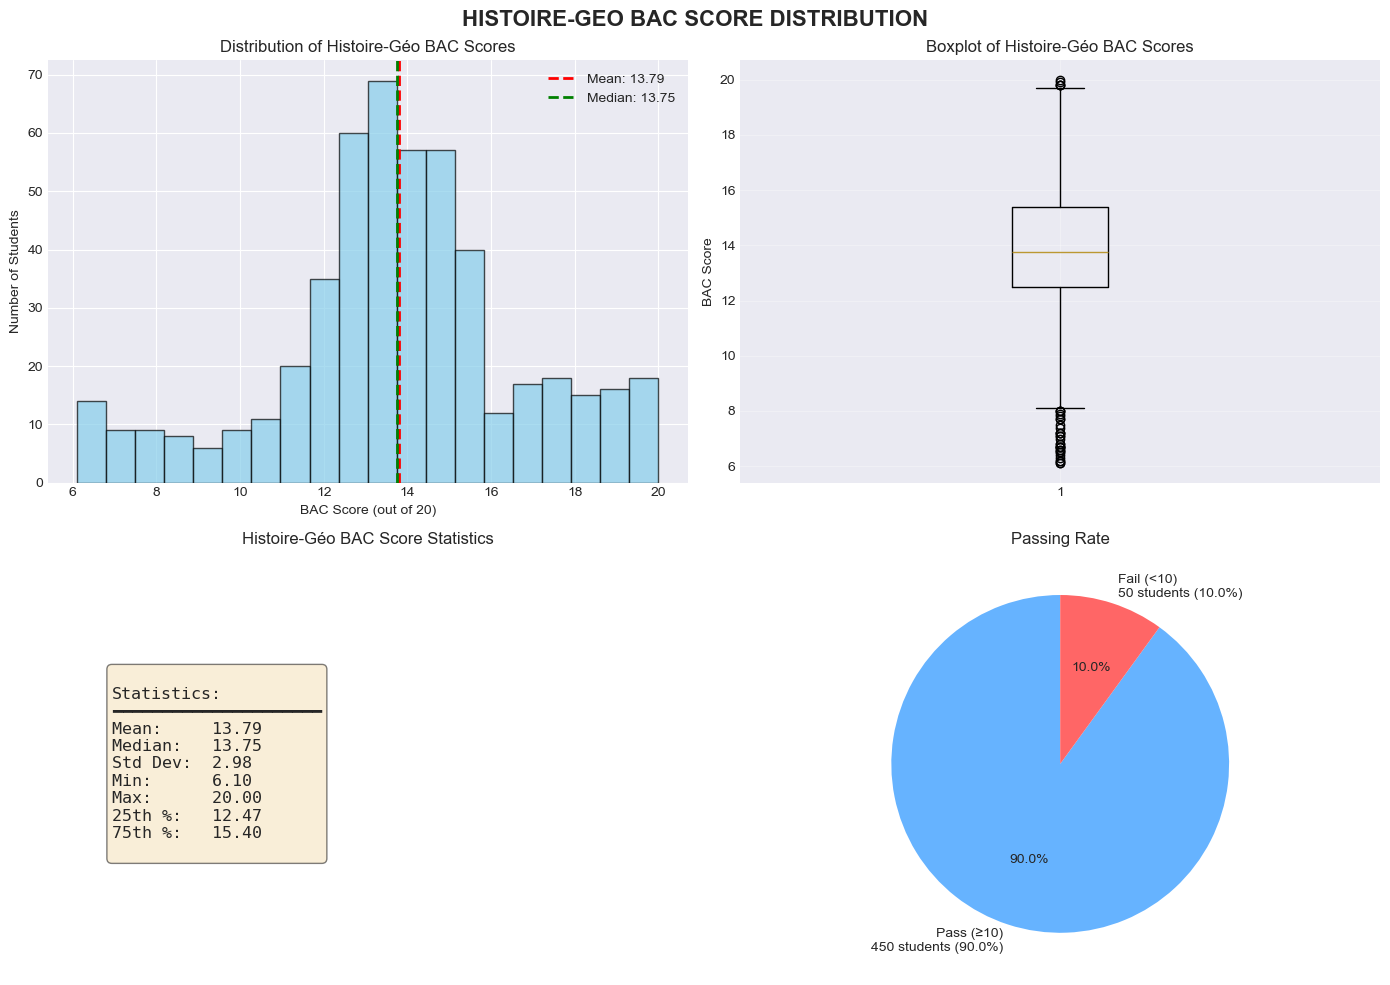


📊 DISTRIBUTION SUMMARY
   Mean:     13.79/20
   Median:   13.75/20
   Std Dev:  2.98
   Pass Rate: 90.0% (450/500)
   Fail Rate: 10.0% (50/500)

✅ Cell 6 complete! Ready for Cell 7


In [6]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0,0].hist(df['bac_score_hg'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score_hg'].mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {df["bac_score_hg"].mean():.2f}')
axes[0,0].axvline(df['bac_score_hg'].median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {df["bac_score_hg"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of Histoire-Géo BAC Scores')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score_hg'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of Histoire-Géo BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score_hg'].mean():.2f}
Median:   {df['bac_score_hg'].median():.2f}
Std Dev:  {df['bac_score_hg'].std():.2f}
Min:      {df['bac_score_hg'].min():.2f}
Max:      {df['bac_score_hg'].max():.2f}
25th %:   {df['bac_score_hg'].quantile(0.25):.2f}
75th %:   {df['bac_score_hg'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('Histoire-Géo BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score_hg'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('HISTOIRE-GEO BAC SCORE DISTRIBUTION', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("📊 DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"   Mean:     {df['bac_score_hg'].mean():.2f}/20")
print(f"   Median:   {df['bac_score_hg'].median():.2f}/20")
print(f"   Std Dev:  {df['bac_score_hg'].std():.2f}")
print(f"   Pass Rate: {passing/len(df)*100:.1f}% ({passing}/{len(df)})")
print(f"   Fail Rate: {failing/len(df)*100:.1f}% ({failing}/{len(df)})")
print("=" * 60)

print("\n✅ Cell 6 complete! Ready for Cell 7")


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score_hg                  : 1.000
   avg_grade                     : 0.675
   grade_t3                      : 0.638
   grade_t2                      : 0.630
   grade_t1                      : 0.627
   essay_method                  : 0.611
   document_analysis_method      : 0.604
   argumentation_skill           : 0.579
   map_stats_method              : 0.531
   geography_knowledge           : 0.528
   historical_memory             : 0.527
   algeria_history_knowledge     : 0.488
   geography_part_structure      : 0.478
   dates_memory                  : 0.476
   history_part_structure        : 0.461


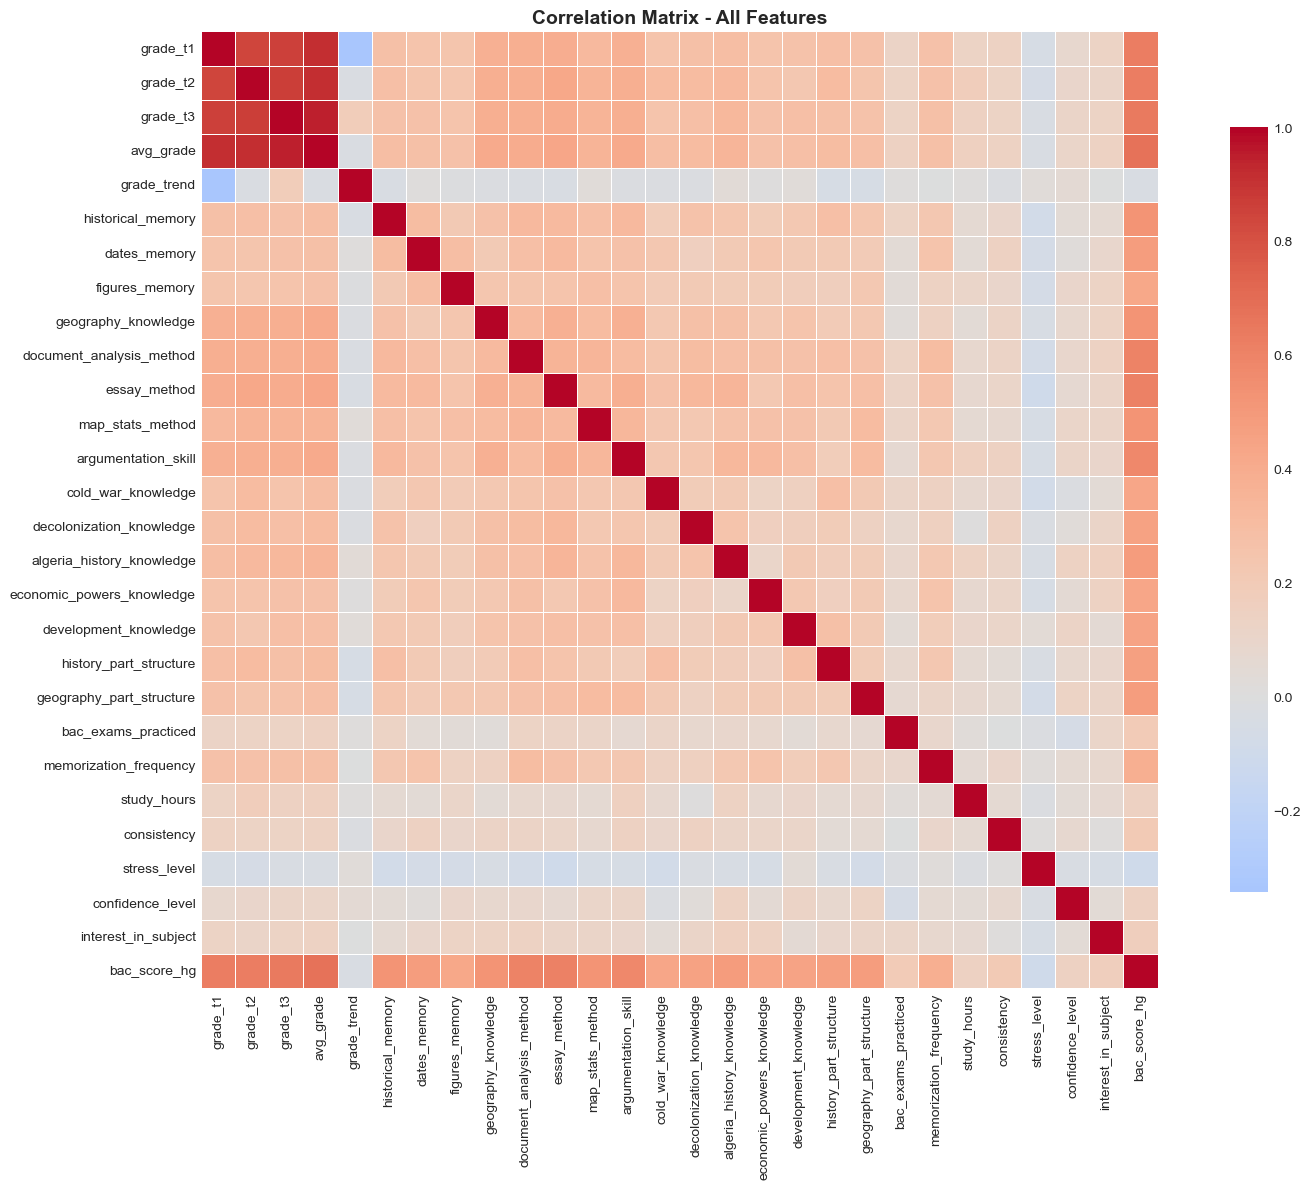

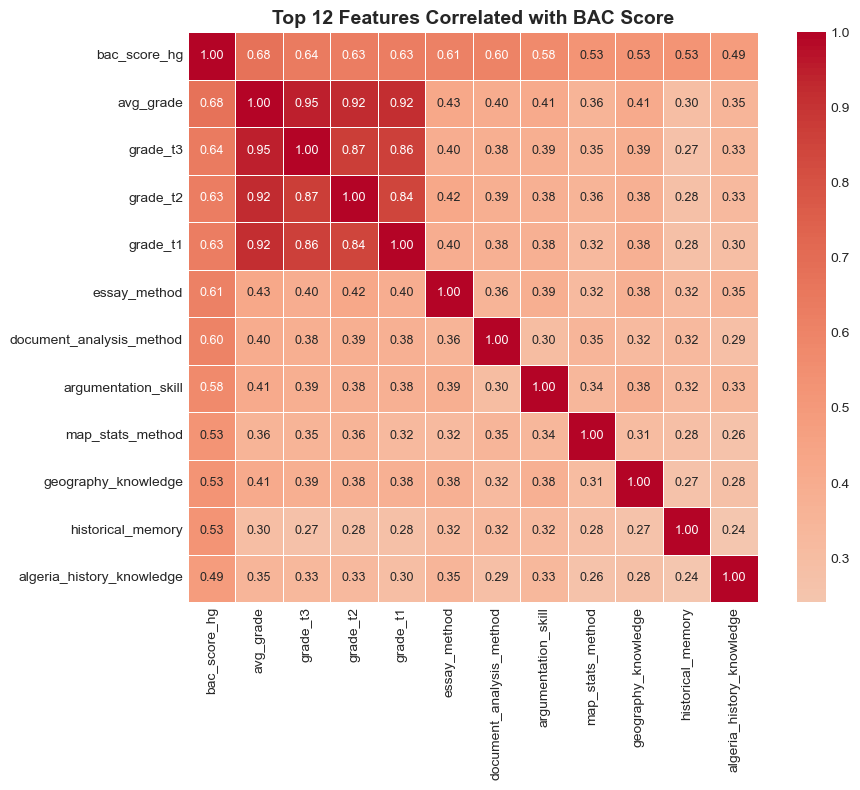

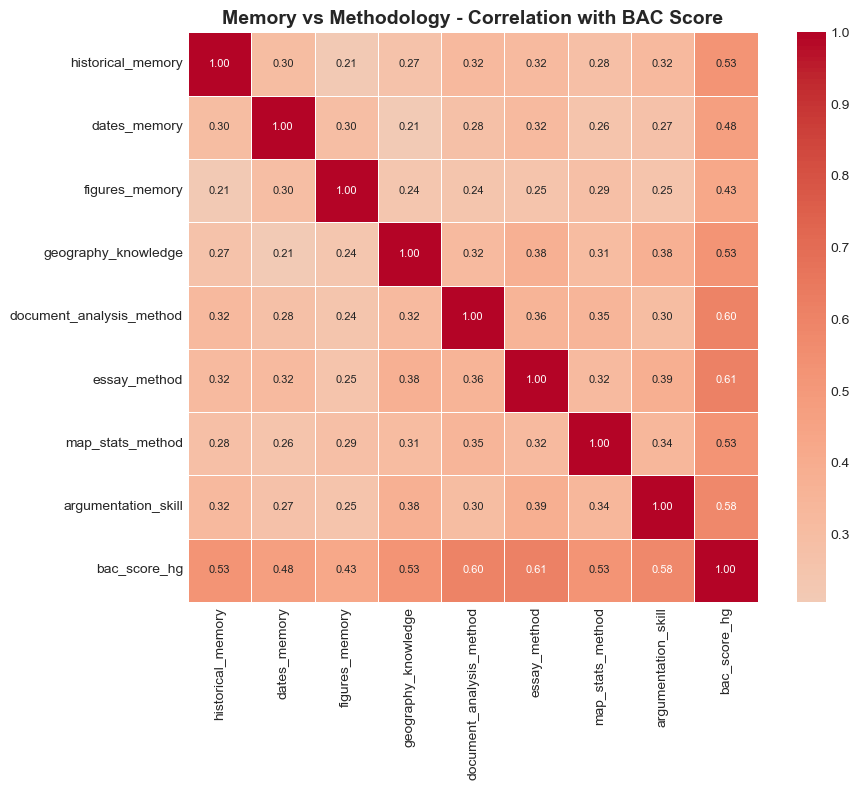


✅ Memory skills avg correlation: 0.489
✅ Methodology skills avg correlation: 0.581

✅ Cell 7 complete! Ready for Cell 8


In [7]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation with target
corr_matrix = df.corr()
bac_corr = corr_matrix['bac_score_hg'].sort_values(ascending=False)

print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 50)
for feature, corr_value in bac_corr.head(15).items():
    print(f"   {feature:30s}: {corr_value:.3f}")

# Heatmap 1: All features
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 2: Top features only
top_features = bac_corr.head(12).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Top 12 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 3: Memory vs Methodology comparison
memory_cols = ['historical_memory', 'dates_memory', 'figures_memory', 'geography_knowledge']
method_cols = ['document_analysis_method', 'essay_method', 'map_stats_method', 'argumentation_skill']
compare_cols = memory_cols + method_cols + ['bac_score_hg']

plt.figure(figsize=(10, 8))
sns.heatmap(df[compare_cols].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
plt.title('Memory vs Methodology - Correlation with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Memory skills avg correlation: {:.3f}".format(df[memory_cols].corrwith(df['bac_score_hg']).mean()))
print("✅ Methodology skills avg correlation: {:.3f}".format(df[method_cols].corrwith(df['bac_score_hg']).mean()))
print("=" * 50)

print("\n✅ Cell 7 complete! Ready for Cell 8")

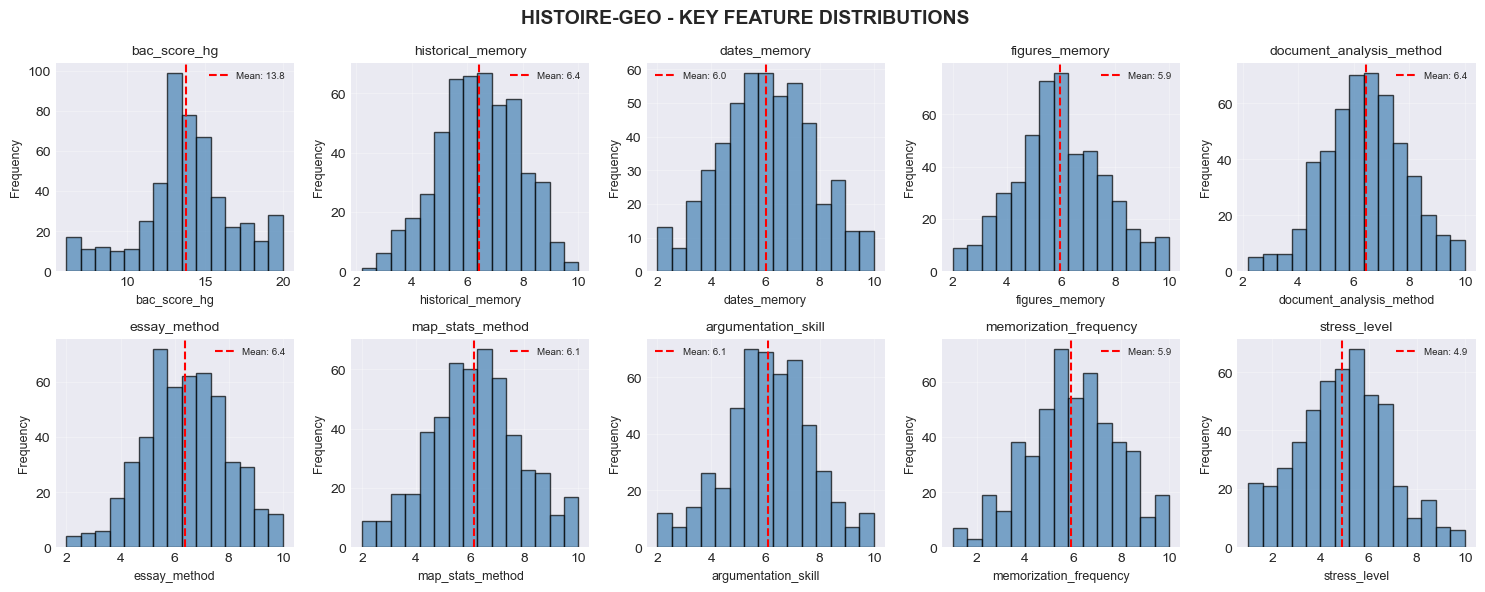


📊 MEMORY SKILLS:
       historical_memory  dates_memory  figures_memory  geography_knowledge
count             500.00        500.00          500.00               500.00
mean                6.42          6.02            5.94                 6.36
std                 1.43          1.73            1.66                 1.54
min                 2.20          2.00            2.00                 2.00
25%                 5.50          4.80            4.80                 5.30
50%                 6.40          6.00            5.90                 6.30
75%                 7.50          7.22            7.00                 7.40
max                10.00         10.00           10.00                10.00

📊 METHODOLOGY SKILLS:
       document_analysis_method  essay_method  map_stats_method  \
count                    500.00        500.00            500.00   
mean                       6.43          6.40              6.15   
std                        1.47          1.53              1.70   
min    

In [8]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS
# ============================================

import matplotlib.pyplot as plt

# Key features to visualize
key_features = ['bac_score_hg', 'historical_memory', 'dates_memory', 'figures_memory',
                'document_analysis_method', 'essay_method', 'map_stats_method', 
                'argumentation_skill', 'memorization_frequency', 'stress_level']

# Filter available features
available_features = [f for f in key_features if f in df.columns]

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('HISTOIRE-GEO - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print("\n📊 MEMORY SKILLS:")
memory_cols = ['historical_memory', 'dates_memory', 'figures_memory', 'geography_knowledge']
print(df[memory_cols].describe().round(2))

print("\n📊 METHODOLOGY SKILLS:")
method_cols = ['document_analysis_method', 'essay_method', 'map_stats_method', 'argumentation_skill']
print(df[method_cols].describe().round(2))

print("\n✅ Cell 8 complete! Ready for Cell 9")

In [9]:
# ============================================
# CELL 9: FEATURE ENGINEERING - HISTOIRE-GEO
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy
df_fe = df.copy()

# 1. Memory composite (average of all memory skills)
memory_cols = ['historical_memory', 'dates_memory', 'figures_memory', 'geography_knowledge']
df_fe['memory_composite'] = df_fe[memory_cols].mean(axis=1).round(1)

# 2. Methodology composite (average of all methodology skills)
method_cols = ['document_analysis_method', 'essay_method', 'map_stats_method', 'argumentation_skill']
df_fe['methodology_composite'] = df_fe[method_cols].mean(axis=1).round(1)

# 3. Knowledge composite (history + geography topics)
knowledge_cols = ['cold_war_knowledge', 'decolonization_knowledge', 'algeria_history_knowledge',
                  'economic_powers_knowledge', 'development_knowledge']
df_fe['knowledge_composite'] = df_fe[knowledge_cols].mean(axis=1).round(1)

# 4. Study quality (memorization frequency + consistency)
df_fe['study_quality'] = (df_fe['memorization_frequency'] * 0.6 + 
                          df_fe['consistency'] * 0.4).round(1)

# 5. Imbalance score (variance between memory and methodology)
df_fe['hg_imbalance'] = df_fe[['memory_composite', 'methodology_composite']].var(axis=1).round(2)

print("\n✅ New features created:")
print("   • memory_composite (0-10) - avg of all memory skills")
print("   • methodology_composite (0-10) - avg of all methodology skills")
print("   • knowledge_composite (0-10) - avg of topic knowledge")
print("   • study_quality (0-10)")
print("   • hg_imbalance (variance between memory & methodology)")

# Update dataframe
df = df_fe.copy()

print(f"\n📊 Total columns now: {df.shape[1]}")
print("✅ Cell 9 complete! Ready for Cell 10")

FEATURE ENGINEERING

✅ New features created:
   • memory_composite (0-10) - avg of all memory skills
   • methodology_composite (0-10) - avg of all methodology skills
   • knowledge_composite (0-10) - avg of topic knowledge
   • study_quality (0-10)
   • hg_imbalance (variance between memory & methodology)

📊 Total columns now: 33
✅ Cell 9 complete! Ready for Cell 10


In [10]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# Define features (X) and target (y)
X = df.drop('bac_score_hg', axis=1)
y = df['bac_score_hg']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score_hg")

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

print("\n✅ Cell 10 complete! Ready for Cell 11")

TRAIN/TEST SPLIT

📊 Features (X): 32 columns
📊 Target (y): bac_score_hg

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

✅ Cell 10 complete! Ready for Cell 11


In [11]:
# ============================================
# CELL 11: MODEL TRAINING - HISTOIRE-GEO
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING - HISTOIRE-GEO")
print("=" * 40)

# Train Random Forest
print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# Feature Importance
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:30s}: {row['importance']:.4f}")

print("\n✅ Cell 11 complete! Ready for Cell 12")

MODEL TRAINING - HISTOIRE-GEO

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  1.03 points
   RMSE: 1.33 points
   R²:   0.787

FEATURE IMPORTANCE

Top 10 most important features:
   methodology_composite         : 0.5615
   knowledge_composite           : 0.1540
   memory_composite              : 0.0501
   avg_grade                     : 0.0249
   history_part_structure        : 0.0202
   historical_memory             : 0.0169
   geography_part_structure      : 0.0133
   geography_knowledge           : 0.0123
   grade_t1                      : 0.0116
   grade_t3                      : 0.0110

✅ Cell 11 complete! Ready for Cell 12


MODEL EVALUATION (DETAILED) - HISTOIRE-GEO

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     1.029 points
   Root Mean Squared Error (RMSE): 1.331 points
   R² Score:                      0.787

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 0.980 (98.0%)

   Confusion Matrix:
   True Negatives (correct fail):  5
   False Positives:                1
   False Negatives:                1
   True Positives (correct pass):  93


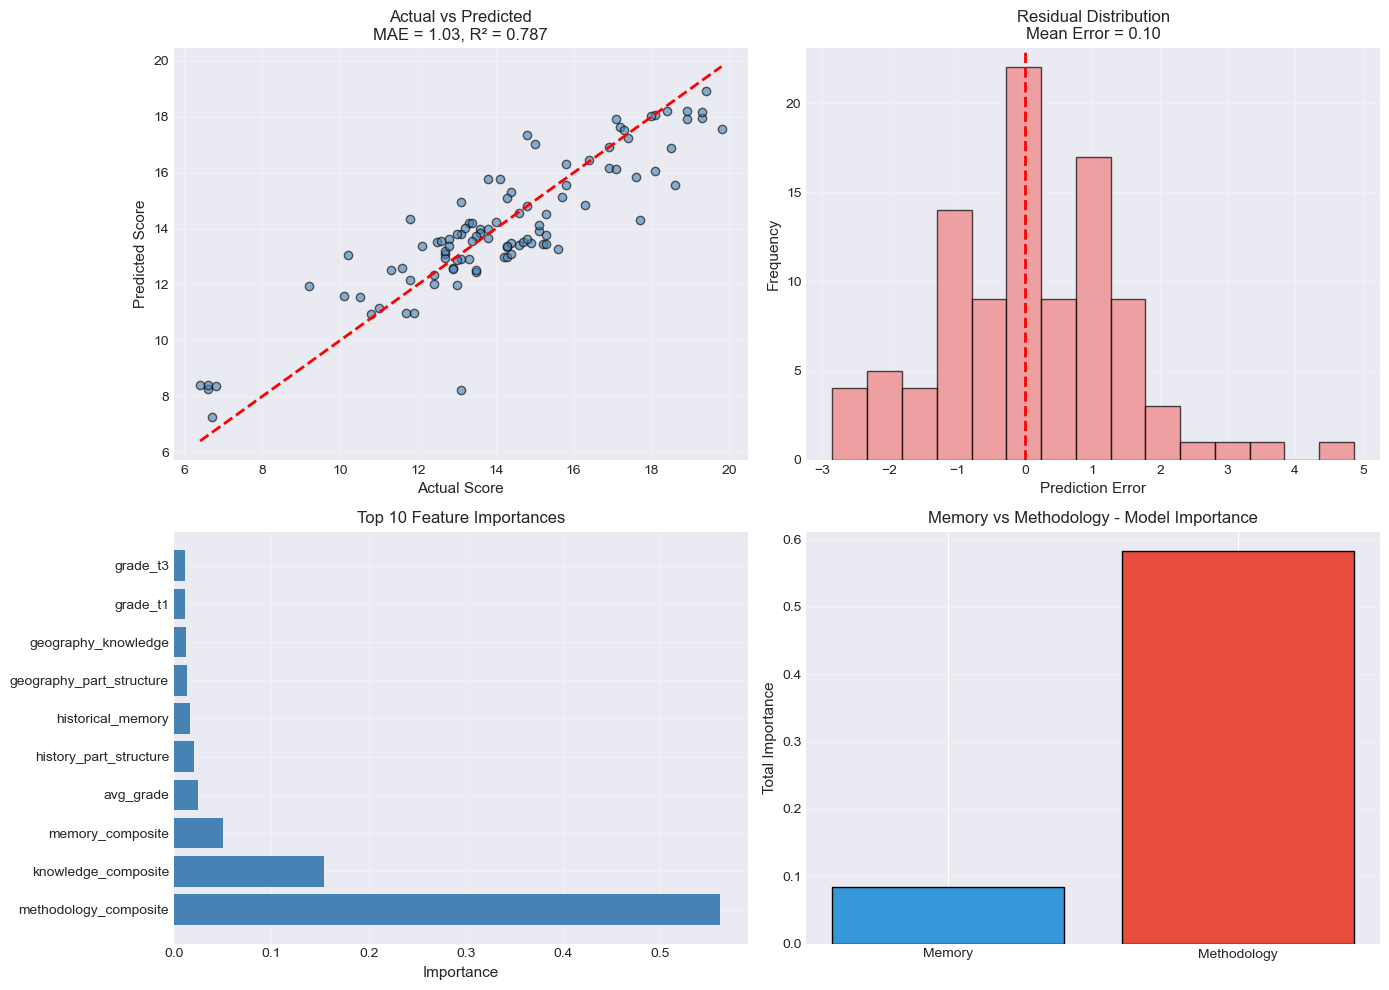


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      1.029 points
   Median Error:    0.926 points
   Error < 1 point: 59.0% of predictions
   Error < 2 points: 88.0% of predictions

✅ Evaluation Complete


In [12]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED) - HISTOIRE-GEO
# ============================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED) - HISTOIRE-GEO")
print("=" * 50)

# 1. Score Prediction Metrics
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# 2. Pass/Fail Classification
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0,0].set_xlabel('Actual Score', fontsize=11)
axes[0,0].set_ylabel('Predicted Score', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted\nMAE = {mae:.2f}, R² = {r2:.3f}', fontsize=12)
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error', fontsize=11)
axes[0,1].set_ylabel('Frequency', fontsize=11)
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 10)
top_features = feature_importance.head(10)
axes[1,0].barh(top_features['feature'], top_features['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance', fontsize=11)
axes[1,0].set_title('Top 10 Feature Importances', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Memory vs Methodology comparison
memory_imp = feature_importance[feature_importance['feature'].isin(['memory_composite', 'historical_memory', 'dates_memory', 'figures_memory'])]['importance'].sum()
method_imp = feature_importance[feature_importance['feature'].isin(['methodology_composite', 'document_analysis_method', 'essay_method', 'argumentation_skill'])]['importance'].sum()
categories = ['Memory', 'Methodology']
values = [memory_imp, method_imp]
colors_bar = ['#3498db', '#e74c3c']
axes[1,1].bar(categories, values, color=colors_bar, edgecolor='black')
axes[1,1].set_ylabel('Total Importance', fontsize=11)
axes[1,1].set_title('Memory vs Methodology - Model Importance', fontsize=12)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. Error Summary
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - HISTOIRE-GEO

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 32)


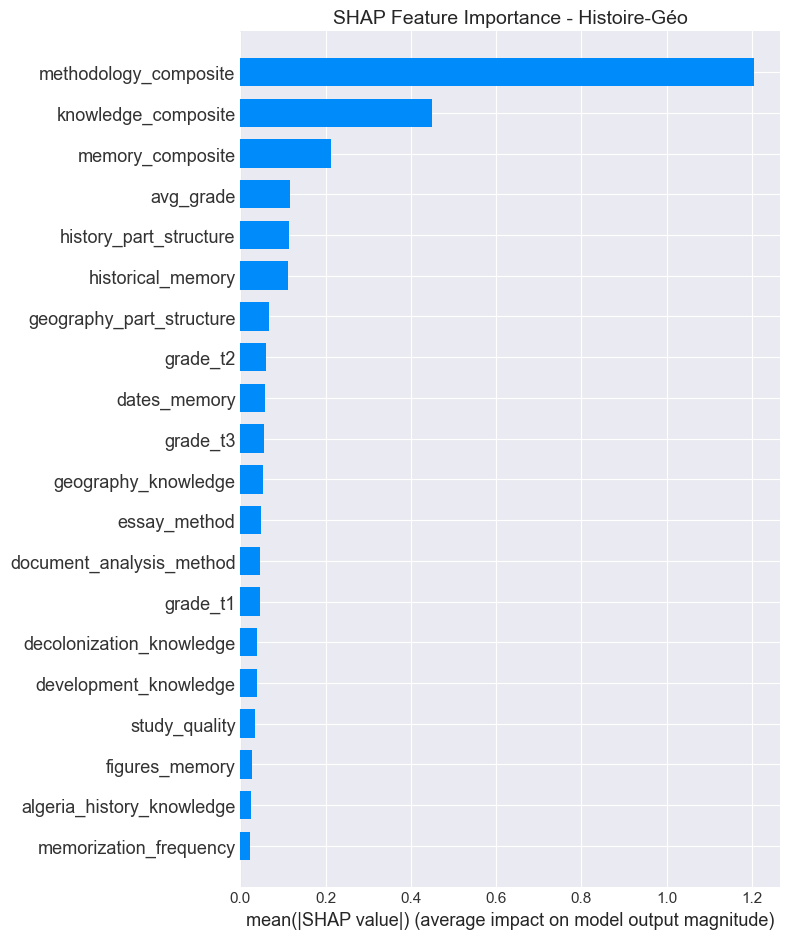

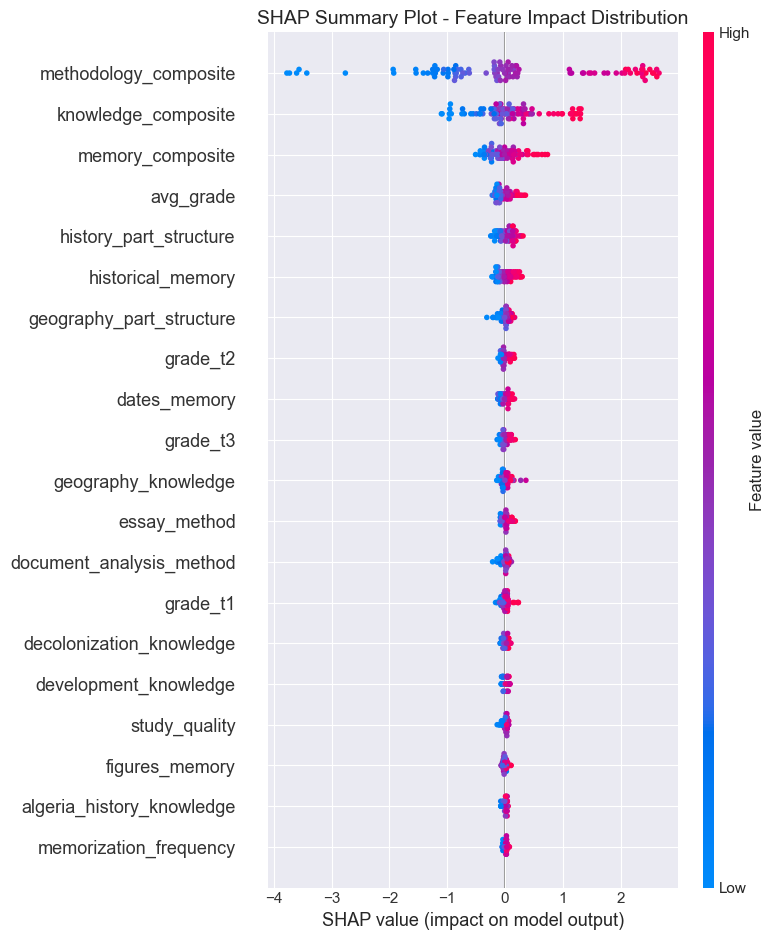


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual score: 12.7
   Predicted score: 13.1


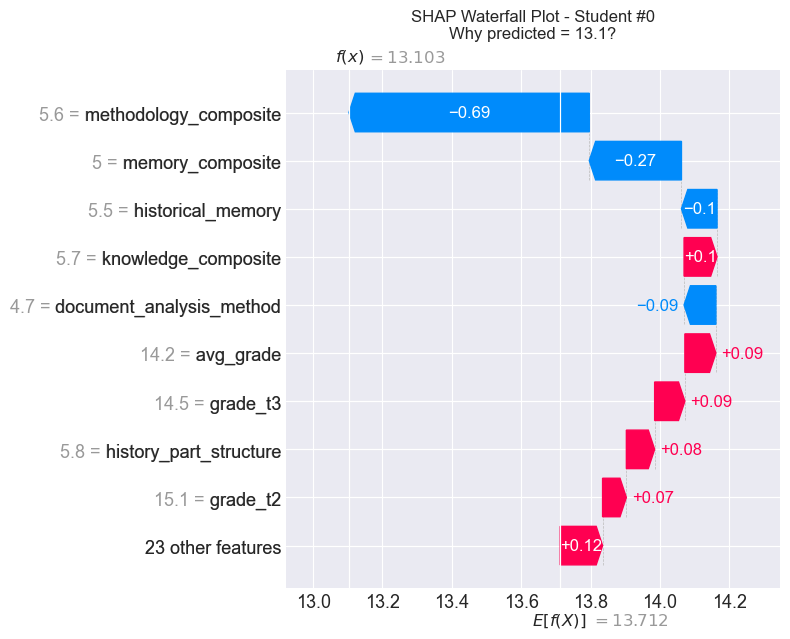


✅ SHAP Explainability Complete


In [13]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - HISTOIRE-GEO
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - HISTOIRE-GEO")
print("=" * 50)

# Create SHAP explainer
print("\n📊 Creating SHAP explainer...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# Visualization 1: Feature Importance (SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Histoire-Géo', fontsize=14)
plt.tight_layout()
plt.show()

# Visualization 2: Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Single student explanation
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual score: {student_actual:.1f}")
print(f"   Predicted score: {student_pred:.1f}")

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [14]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS - HISTOIRE-GEO
# ============================================

from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - HISTOIRE-GEO")
print("=" * 50)

# Get feature names and SHAP values
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Weaknesses (negative contributions)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Strengths (positive contributions)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    # Safely get strings
    w1 = f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None"
    w2 = f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None"
    w3 = f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None"
    
    s1 = f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None"
    s2 = f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None"
    s3 = f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None"
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': w1,
        'weakness_2': w2,
        'weakness_3': w3,
        'strength_1': s1,
        'strength_2': s2,
        'strength_3': s3,
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# Display first 10 students
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses: {row['weakness_1']} | {row['weakness_2']} | {row['weakness_3']}")
    print(f"   🟢 Strengths: {row['strength_1']} | {row['strength_2']} | {row['strength_3']}")

# Most common weaknesses
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 10 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(10):
    print(f"   • {feature}: {count} students")

# Recommendations
print("\n" + "=" * 50)
print("💡 RECOMMENDATIONS")
print("=" * 50)

recommendations = {
    'historical_memory': '📚 راجع الأحداث التاريخية الكبرى - حافظ على التواريخ الأساسية',
    'dates_memory': '📅 احفظ التواريخ الرئيسية (1945, 1954, 1962, 1989...)',
    'figures_memory': '👤 تعرف على الشخصيات التاريخية وأدوارها',
    'document_analysis_method': '📄 تدرب على تحليل النصوص والخرائط (استخراج الأفكار الأساسية)',
    'essay_method': '✍️ تعلم هيكلة المقال: مقدمة → عرض → خاتمة',
    'map_stats_method': '🗺️ تدرب على قراءة الخرائط والإحصاءات والتعليق عليها',
    'argumentation_skill': '🎯 طور قدرتك على بناء حجج منطقية مترابطة',
    'memory_composite': '🧠 راجع المعلومات بانتظام - الذاكرة تحتاج إلى تكرار',
    'methodology_composite': '📝 أتقن المنهجية - كيف تجيب على كل نوع من الأسئلة',
    'geography_knowledge': '🌍 راجع المفاهيم الجغرافية (التنمية، التكتلات، الموارد)',
    'algeria_history_knowledge': '🇩🇿 ركز على تاريخ الجزائر (الثورة، الاستقلال، بناء الدولة)',
    'cold_war_knowledge': '🌍 راجع الحرب الباردة: الأطراف، الأزمات، النهاية',
    'hg_imbalance': '⚖️ وازن بين ذاكرتك ومنهجيتك - الاثنان مهمان بنفس القدر'
}

print("\n📋 Based on common weaknesses:")
for feature, count in weakness_counts.most_common(8):
    if feature in recommendations:
        print(f"   • {recommendations[feature]}")
    else:
        print(f"   • {feature}: ركز على تحسين هذا المجال")

# Save
weakness_df.to_csv('weakness_analysis_hg.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_hg.csv'")
print("=" * 50)

WEAKNESS ANALYSIS - HISTOIRE-GEO

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=12.7, Predicted=13.1
   🔴 Weaknesses: methodology_composite (-0.69) | memory_composite (-0.27) | historical_memory (-0.10)
   🟢 Strengths: knowledge_composite (+0.10) | avg_grade (+0.09) | grade_t3 (+0.09)

🔹 STUDENT 2: Actual=18.6, Predicted=15.6
   🔴 Weaknesses: map_stats_method (-0.05) | essay_method (-0.03) | stress_level (-0.03)
   🟢 Strengths: knowledge_composite (+0.92) | historical_memory (+0.21) | memory_composite (+0.14)

🔹 STUDENT 3: Actual=15.1, Predicted=13.9
   🔴 Weaknesses: memory_composite (-0.24) | historical_memory (-0.16) | geography_part_structure (-0.08)
   🟢 Strengths: methodology_composite (+0.24) | knowledge_composite (+0.22) | study_quality (+0.06)

🔹 STUDENT 4: Actual=16.9, Predicted=16.9
   🔴 Weaknesses: history_part_structure (-0.13) | knowledge_composite (-0.12) | avg_grade (-0.11)
   🟢 Strengths: methodology_compo

SIMULATION ENGINE - HISTOIRE-GEO
How improving memory & methodology affects your score

👤 Average student profile:
   Current score: 13.8/20
   Memory composite: 6.2/10
   Methodology composite: 6.6/10
   Document analysis: 6.2/10
   Essay method: 7.5/10

📈 SIMULATION RESULTS:
-------------------------------------------------------

⚪ 📄 تحسين تحليل الوثائق +2:
   13.8 → 14.0 (+0.24)

⚪ ✍️ تحسين هيكلة المقال +2:
   13.8 → 14.0 (+0.24)

⚪ 🧠 تحسين الذاكرة التاريخية +2:
   13.8 → 14.0 (+0.20)

⚪ 🎯 تحسين الحجاج والمنطق +2:
   13.8 → 14.0 (+0.20)

⚪ 🗺️ تحسين قراءة الخرائط والإحصاءات +2:
   13.8 → 14.0 (+0.16)

⚪ 📅 تحسين حفظ التواريخ +2:
   13.8 → 14.0 (+0.16)

⚪ 🇩🇿 تحسين تاريخ الجزائر +2:
   13.8 → 13.9 (+0.14)

⚪ 📚 زيادة التمارين (5 امتحانات):
   13.8 → 14.0 (+0.15)

⚪ 😌 تقليل التوتر -2 (تأثير ضئيل):
   13.8 → 13.8 (+0.04)

🟢 ✨ تحسين كل المهارات الأساسية (+2 لكل منها):
   13.8 → 15.0 (+1.20)

🎯 BEST RECOMMENDATION

✅ 📄 تحسين تحليل الوثائق +2
   → Expected improvement: +0.24 points


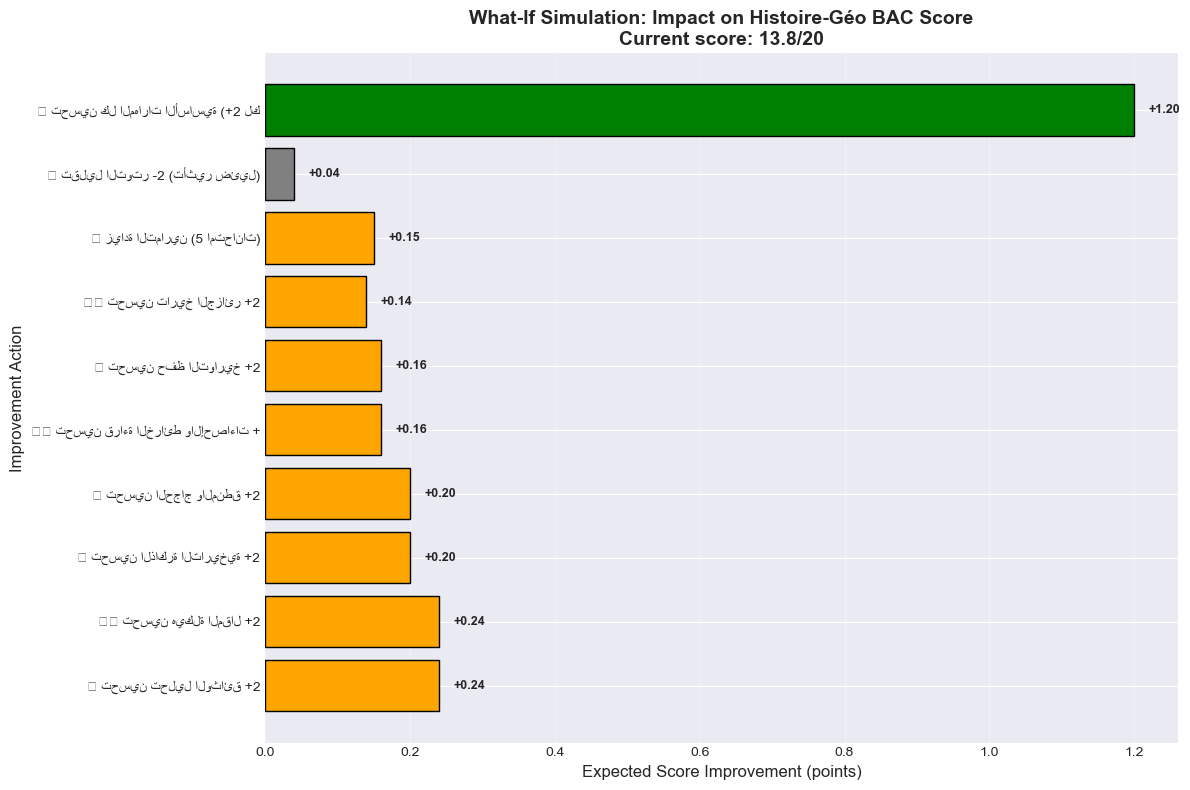


📊 IMPACT TABLE
                 Skill Expected Gain
    📄 تحليل الوثائق +2     +0.24 pts
    ✍️ هيكلة المقال +2     +0.24 pts
🧠 الذاكرة التاريخية +2     +0.20 pts
   🎯 الحجاج والمنطق +2     +0.20 pts
   🗺️ قراءة الخرائط +2     +0.16 pts
     📅 حفظ التواريخ +2     +0.16 pts

💡 KEY INSIGHTS:
   • METHODOLOGY (document analysis + essay structure) = MOST IMPORTANT
   • MEMORY (dates, facts, figures) = ESSENTIAL foundation
   • PRACTICE has LOW impact (just for familiarity, not repetition)
   • STRESS has VERY LOW impact - these subjects are not stressful
   • Balance between memory and methodology = KEY to success

✅ Simulation Engine Complete


In [15]:
# ============================================
# CELL 15: SIMULATION ENGINE - HISTOIRE-GEO
# ============================================

import matplotlib.pyplot as plt

print("=" * 60)
print("SIMULATION ENGINE - HISTOIRE-GEO")
print("How improving memory & methodology affects your score")
print("=" * 60)

# Impact factors (based on correlations)
impact_factors = {
    'document_analysis_method': 0.12,  # HIGHEST
    'essay_method': 0.12,              # HIGHEST
    'historical_memory': 0.10,
    'argumentation_skill': 0.10,
    'memory_composite': 0.09,
    'methodology_composite': 0.09,
    'dates_memory': 0.08,
    'geography_knowledge': 0.08,
    'map_stats_method': 0.08,
    'algeria_history_knowledge': 0.07,
    'memorization_frequency': 0.06,
    'bac_exams_practiced': 0.03,       # LOW impact
    'stress_level': -0.02              # VERY LOW
}

# Find average student
avg_bac = df['bac_score_hg'].mean()
target_student = df.iloc[(df['bac_score_hg'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Average student profile:")
print(f"   Current score: {target_student['bac_score_hg']:.1f}/20")
print(f"   Memory composite: {target_student.get('memory_composite', 5):.1f}/10")
print(f"   Methodology composite: {target_student.get('methodology_composite', 5):.1f}/10")
print(f"   Document analysis: {target_student.get('document_analysis_method', 5):.1f}/10")
print(f"   Essay method: {target_student.get('essay_method', 5):.1f}/10")

# Simulation function
def simulate_improvement(student, improvements):
    original = student['bac_score_hg']
    gain = 0
    
    for skill, delta in improvements.items():
        if skill in impact_factors:
            gain += delta * impact_factors[skill]
    
    new_score = min(original + gain, 20)
    new_score = max(new_score, 0)
    return {'original': original, 'new': new_score, 'gain': gain}

# Scenarios
scenarios = [
    ("📄 تحسين تحليل الوثائق +2", {"document_analysis_method": 2}),
    ("✍️ تحسين هيكلة المقال +2", {"essay_method": 2}),
    ("🧠 تحسين الذاكرة التاريخية +2", {"historical_memory": 2}),
    ("🎯 تحسين الحجاج والمنطق +2", {"argumentation_skill": 2}),
    ("🗺️ تحسين قراءة الخرائط والإحصاءات +2", {"map_stats_method": 2}),
    ("📅 تحسين حفظ التواريخ +2", {"dates_memory": 2}),
    ("🇩🇿 تحسين تاريخ الجزائر +2", {"algeria_history_knowledge": 2}),
    ("📚 زيادة التمارين (5 امتحانات)", {"bac_exams_practiced": 5}),
    ("😌 تقليل التوتر -2 (تأثير ضئيل)", {"stress_level": -2}),
    ("✨ تحسين كل المهارات الأساسية (+2 لكل منها)", {
        "document_analysis_method": 2, "essay_method": 2, "historical_memory": 2,
        "argumentation_skill": 2, "map_stats_method": 2, "dates_memory": 2
    })
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 55)

results = []
for name, changes in scenarios:
    result = simulate_improvement(target_student, changes)
    results.append(result)
    
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {name}:")
    print(f"   {result['original']:.1f} → {result['new']:.1f} (+{result['gain']:.2f})")

# Best recommendation
best_idx = max(range(len(results)-1), key=lambda i: results[i]['gain'])
best_scenario = scenarios[best_idx]
best_gain = results[best_idx]['gain']

print("\n" + "=" * 60)
print("🎯 BEST RECOMMENDATION")
print("=" * 60)
print(f"\n✅ {best_scenario[0]}")
print(f"   → Expected improvement: +{best_gain:.2f} points")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

scenario_names = [s[0][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on Histoire-Géo BAC Score\nCurrent score: {target_student["bac_score_hg"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 60)
print("📊 IMPACT TABLE")
print("=" * 60)

impact_table = pd.DataFrame({
    'Skill': [
        '📄 تحليل الوثائق +2',
        '✍️ هيكلة المقال +2',
        '🧠 الذاكرة التاريخية +2',
        '🎯 الحجاج والمنطق +2',
        '🗺️ قراءة الخرائط +2',
        '📅 حفظ التواريخ +2'
    ],
    'Expected Gain': [
        f'+{impact_factors["document_analysis_method"]*2:.2f} pts',
        f'+{impact_factors["essay_method"]*2:.2f} pts',
        f'+{impact_factors["historical_memory"]*2:.2f} pts',
        f'+{impact_factors["argumentation_skill"]*2:.2f} pts',
        f'+{impact_factors["map_stats_method"]*2:.2f} pts',
        f'+{impact_factors["dates_memory"]*2:.2f} pts'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 KEY INSIGHTS:")
print("   • METHODOLOGY (document analysis + essay structure) = MOST IMPORTANT")
print("   • MEMORY (dates, facts, figures) = ESSENTIAL foundation")
print("   • PRACTICE has LOW impact (just for familiarity, not repetition)")
print("   • STRESS has VERY LOW impact - these subjects are not stressful")
print("   • Balance between memory and methodology = KEY to success")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [16]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - HISTOIRE-GEO
# ============================================

print("=" * 60)
print("📖 فهم نتائجك في التاريخ والجغرافيا")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# Sample student
sample_student = df.iloc[50]

print(f"\n👤 ملف الطالب:")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score_hg']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# Memory Skills
print("\n📚 الذاكرة والمعلومات (الجزء الأول من النجاح)")
print("-" * 60)

memory_skills = [
    ('historical_memory', '📜 الأحداث التاريخية', 'راجع الأحداث الكبرى وأسبابها ونتائجها'),
    ('dates_memory', '📅 التواريخ المهمة', 'احفظ التواريخ الأساسية (1945، 1954، 1962، 1989...)'),
    ('figures_memory', '👤 الشخصيات التاريخية', 'تعرف على أدوار الشخصيات الرئيسية'),
    ('geography_knowledge', '🌍 المفاهيم الجغرافية', 'افهم مصطلحات التنمية، التكتلات، الموارد')
]

for skill, name, advice in memory_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Methodology Skills
print("\n" + "=" * 60)
print("📝 المنهجية (الجزء الثاني من النجاح - الأهم!)")
print("=" * 60)

method_skills = [
    ('document_analysis_method', '📄 تحليل الوثائق (نصوص، خرائط، إحصاءات)',
     'تدرب على استخراج الأفكار الأساسية من الوثائق'),
    ('essay_method', '✍️ هيكلة المقال',
     'تعلم كتابة المقال: مقدمة → عرض → خاتمة'),
    ('map_stats_method', '🗺️ قراءة الخرائط والإحصاءات',
     'تدرب على التعليق على الخرائط والأرقام'),
    ('argumentation_skill', '🎯 الحجاج والمنطق',
     'طور قدرتك على بناء حجج منطقية مترابطة')
]

for skill, name, advice in method_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Study Habits
print("\n" + "=" * 60)
print("📖 عادات الدراسة")
print("=" * 60)

print(f"\n📚 وتيرة الحفظ: {sample_student['memorization_frequency']:.1f}/10")
print(f"⏰ ساعات الدراسة الأسبوعية: {sample_student['study_hours']:.1f}/10")
print(f"📅 الانتظام: {sample_student['consistency']:.1f}/10")

if sample_student['memorization_frequency'] < 6:
    print("   💡 نصيحة: راجع المعلومات بانتظام - الذاكرة تحتاج إلى تكرار")
if sample_student['study_hours'] < 3:
    print("   💡 نصيحة: خصص 3-4 ساعات أسبوعياً للمراجعة")

# Psychological Factors (VERY LOW impact)
print("\n" + "=" * 60)
print("🧠 العوامل النفسية (تأثيرها ضعيف جداً)")
print("=" * 60)

print(f"\n😰 مستوى التوتر: {sample_student['stress_level']:.1f}/10")
print(f"💪 الثقة: {sample_student['confidence_level']:.1f}/10")
print(f"❤️ الاهتمام بالمادة: {sample_student['interest_in_subject']:.1f}/10")
print("   💡 نصيحة: التاريخ والجغرافيا ليسا مواد مرهقة - ثق بنفسك!")

# Composite scores
print("\n" + "=" * 60)
print("📊 مؤشراتك المركبة")
print("=" * 60)

memory_comp = sample_student.get('memory_composite', (sample_student['historical_memory'] + sample_student['dates_memory'] + sample_student['figures_memory'] + sample_student['geography_knowledge']) / 4)
method_comp = sample_student.get('methodology_composite', (sample_student['document_analysis_method'] + sample_student['essay_method'] + sample_student['map_stats_method'] + sample_student['argumentation_skill']) / 4)

print(f"\n🧠 مستوى الذاكرة: {memory_comp:.1f}/10")
print(f"📝 مستوى المنهجية: {method_comp:.1f}/10")

if memory_comp >= 7 and method_comp >= 7:
    print("   ✅ ممتاز! أنت متوازن بين الذاكرة والمنهجية")
elif memory_comp > method_comp:
    print("   📚 ذاكرتك قوية لكن منهجيتك تحتاج إلى تحسين")
    print("   💡 ركز على كيفية تحليل الوثائق وكتابة المقال")
else:
    print("   ✍️ منهجيتك جيدة لكن ذاكرتك تحتاج إلى تقوية")
    print("   💡 راجع التواريخ والأحداث والشخصيات بانتظام")

# Final recommendations
print("\n" + "=" * 60)
print("🎯 توصيات مخصصة لك")
print("=" * 60)

recommendations_list = []

if sample_student['document_analysis_method'] < 6:
    recommendations_list.append("• 📄 تدرب على تحليل الوثائق (نصوص، خرائط، جداول إحصائية)")
if sample_student['essay_method'] < 6:
    recommendations_list.append("• ✍️ تعلم هيكلة المقال: مقدمة → عرض (أفكار مترابطة) → خاتمة")
if sample_student['historical_memory'] < 6:
    recommendations_list.append("• 📜 راجع الأحداث التاريخية الكبرى (الحرب الباردة، التحرر، تاريخ الجزائر)")
if sample_student['dates_memory'] < 5.5:
    recommendations_list.append("• 📅 احفظ التواريخ الأساسية (1945، 1954، 1962، 1989، 1990...)")
if sample_student['argumentation_skill'] < 6:
    recommendations_list.append("• 🎯 طور قدرتك على بناء حجج منطقية مترابطة")
if sample_student['map_stats_method'] < 6:
    recommendations_list.append("• 🗺️ تدرب على قراءة الخرائط والإحصاءات والتعليق عليها")

if recommendations_list:
    for rec in recommendations_list[:5]:
        print(f"   {rec}")
else:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: النجاح في التاريخ والجغرافيا = ذاكرة قوية + منهجية صحيحة")
print(f"   نقطتك الحالية: {sample_student['bac_score_hg']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في التاريخ والجغرافيا
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   النقطة المتوقعة في البكالوريا: 8.4/20
   معدل الفصول الثلاثة: 8.0/20

------------------------------------------------------------

📚 الذاكرة والمعلومات (الجزء الأول من النجاح)
------------------------------------------------------------

📜 الأحداث التاريخية: 8.4/10
   → مستواك: 🟢 قوي
   💡 نصيحة: راجع الأحداث الكبرى وأسبابها ونتائجها

📅 التواريخ المهمة: 5.0/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: احفظ التواريخ الأساسية (1945، 1954، 1962، 1989...)

👤 الشخصيات التاريخية: 5.9/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تعرف على أدوار الشخصيات الرئيسية

🌍 المفاهيم الجغرافية: 7.1/10
   → مستواك: 🟢 قوي
   💡 نصيحة: افهم مصطلحات التنمية، التكتلات، الموارد

📝 المنهجية (الجزء الثاني من النجاح - الأهم!)

📄 تحليل الوثائق (نصوص، خرائط، إحصاءات): 5.3/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تدرب على استخراج الأفكار الأساسية من الوثائق

✍️ هيكلة المقال: 6.5/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تعلم كتابة المقال: مقدمة → عرض → خاتمة


In [17]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - HISTOIRE-GEO
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("📜 منصة تحسين الأداء في التاريخ والجغرافيا - البكالوريا الجزائرية (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📜 امتحان البكالوريا - التاريخ والجغرافيا</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعبة: تسيير واقتصاد</p>
        <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.8;">المدة: 3 ساعات و30 دقيقة | المجموع: 20 نقطة</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة</div>
            <div style="font-size: 14px;">3 ساعات و30 دقيقة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">أجزاء الامتحان</div>
            <div style="font-size: 14px;">4 أجزاء</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في التاريخ والجغرافيا</h2>
    </div>
"""

# Exam structure details
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📝 أجزاء الامتحان</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">الجزء</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>الجزء الأول</strong></td>
                <td style="padding: 10px;">التاريخ: تحليل وثيقة + تعريف شخصيات وأحداث</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الثاني</strong></td>
                <td style="padding: 10px;">التاريخ: مقال (الثورة الجزائرية أو العلاقات الدولية)</td>
                <td style="padding: 10px; text-align: center;">4 نقاط</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>الجزء الثالث</strong></td>
                <td style="padding: 10px;">الجغرافيا: تحليل إحصاءات/خريطة + تعليق</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
             </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الرابع</strong></td>
                <td style="padding: 10px;">الجغرافيا: مقال (القوى الاقتصادية أو التنمية)</td>
                <td style="padding: 10px; text-align: center;">4 نقاط</td>
             </tr>
         </table>
    </div>
"""

# Importance by skill
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 المهارات الأكثر أهمية</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>المنهجية</strong></div>
                <div style="font-size: 12px; color: #666;">تحليل الوثائق + كتابة المقال</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>الذاكرة</strong></div>
                <div style="font-size: 12px; color: #666;">تواريخ، أحداث، شخصيات</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>المعرفة الجغرافية</strong></div>
                <div style="font-size: 12px; color: #666;">مفاهيم، تكتلات، موارد</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>الممارسة</strong></div>
                <div style="font-size: 12px; color: #666;">تأثيرها محدود</div>
            </div>
        </div>
    </div>
"""

# Critical note
note_html = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">📋 ملاحظة مهمة (مختلف عن المواد الأخرى!)</h3>
        <p style="line-height: 1.6;">
            • <strong>المنهجية هي المفتاح</strong> - تعلم كيف تحلل الوثائق وتكتب المقال<br>
            • <strong>الذاكرة ضرورية</strong> - لا يمكنك تزييف معرفة التواريخ والأحداث<br>
            • <strong>الممارسة ليست كالتسيير</strong> - حل التمارين المتكرر لا يفيد كثيراً<br>
            • <strong>التوتر تأثيره ضعيف جداً</strong> - هذه المواد ليست مرهقة<br>
            • <strong>التوازن</strong> = ذاكرة قوية + منهجية صحيحة
        </p>
    </div>
"""

# How it works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>أدخل معلوماتك</strong> - مستواك في الذاكرة والمنهجية</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - هل مشكلتك في الذاكرة أم المنهجية؟</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تحسين مهاراتك وشاهد كيف تتغير نتيجتك</li>
            <li>🎯 <strong>توصيات مخصصة</strong> - نصائح محددة لمساعدتك على رفع نقطتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + importance_html + note_html + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا (شعبة تسيير واقتصاد) على تحسين أدائهم</p>
        <p style="color: #888; font-size: 12px;">📜 تذكر: النجاح = ذاكرة قوية + منهجية صحيحة 📜</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

📜 منصة تحسين الأداء في التاريخ والجغرافيا - البكالوريا الجزائرية (شعبة تسيير واقتصاد)


الجزء,المحتوى,النقاط
الجزء الأول,التاريخ: تحليل وثيقة + تعريف شخصيات وأحداث,6 نقاط
الجزء الثاني,التاريخ: مقال (الثورة الجزائرية أو العلاقات الدولية),4 نقاط
الجزء الثالث,الجغرافيا: تحليل إحصاءات/خريطة + تعليق,6 نقاط
الجزء الرابع,الجغرافيا: مقال (القوى الاقتصادية أو التنمية),4 نقاط



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [18]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - HISTOIRE-GEO
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - التاريخ والجغرافيا (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">جميع المعلومات سرية وتستخدم فقط لحساب توقع نقطتك</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 1. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 2: Memory Skills (CRITICAL)
# ============================================

memory_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 2. الذاكرة والمعلومات (جزء أساسي من النجاح)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0=ضعيف، 10=ممتاز)</p>
</div>
"""
display(HTML(memory_html))

skill_style = widgets.Layout(width='100%', padding='5px')

historical_memory = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='📜 الأحداث التاريخية (أسباب، نتائج):', 
                                         style={'description_width': '250px'}, layout=skill_style)
dates_memory = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='📅 التواريخ المهمة:', 
                                    style={'description_width': '250px'}, layout=skill_style)
figures_memory = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                      description='👤 الشخصيات التاريخية:', 
                                      style={'description_width': '250px'}, layout=skill_style)
geography_knowledge = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                           description='🌍 المفاهيم الجغرافية:', 
                                           style={'description_width': '250px'}, layout=skill_style)

display(historical_memory, dates_memory, figures_memory, geography_knowledge)

# ============================================
# SECTION 3: Methodology Skills (MOST IMPORTANT)
# ============================================

method_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">📝 3. المنهجية (الأهم في البكالوريا!)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(method_html))

document_analysis = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='📄 تحليل الوثائق (نصوص، خرائط، إحصاءات):', 
                                         style={'description_width': '300px'}, layout=skill_style)
essay_method = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='✍️ كتابة المقال (مقدمة، عرض، خاتمة):', 
                                    style={'description_width': '300px'}, layout=skill_style)
map_stats_method = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='🗺️ قراءة الخرائط والإحصاءات:', 
                                        style={'description_width': '300px'}, layout=skill_style)
argumentation = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='🎯 الحجاج والمنطق:', 
                                     style={'description_width': '300px'}, layout=skill_style)

display(document_analysis, essay_method, map_stats_method, argumentation)

# ============================================
# SECTION 4: Topic Knowledge
# ============================================

knowledge_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 4. المعرفة الخاصة بالموضوعات</h3>
    <p style="color: #666; font-size: 14px;">قيم معرفتك من 0 إلى 10</p>
</div>
"""
display(HTML(knowledge_html))

cold_war = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                description='🌍 الحرب الباردة:', 
                                style={'description_width': '250px'}, layout=skill_style)
decolonization = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                      description='🕊️ حركات التحرر:', 
                                      style={'description_width': '250px'}, layout=skill_style)
algeria_history = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                       description='🇩🇿 تاريخ الجزائر (الثورة، الاستقلال):', 
                                       style={'description_width': '250px'}, layout=skill_style)
economic_powers = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                       description='💰 القوى الاقتصادية الكبرى:', 
                                       style={'description_width': '250px'}, layout=skill_style)
development = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                   description='📈 التنمية والعالم الثالث:', 
                                   style={'description_width': '250px'}, layout=skill_style)

display(cold_war, decolonization, algeria_history, economic_powers, development)

# ============================================
# SECTION 5: Study Behavior
# ============================================

study_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #1abc9c;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 5. عادات الدراسة</h3>
</div>
"""
display(HTML(study_html))

memorization_freq = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                         description='📚 وتيرة الحفظ (1-10):', 
                                         style={'description_width': '250px'}, layout=skill_style)
study_hours = widgets.FloatSlider(value=4, min=1, max=10, step=0.5, 
                                   description='⏰ ساعات الدراسة الأسبوعية:', 
                                   style={'description_width': '250px'}, layout=skill_style)
consistency = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                   description='📅 الانتظام في الدراسة (1-10):', 
                                   style={'description_width': '250px'}, layout=skill_style)
bac_practiced = widgets.IntSlider(value=3, min=0, max=15, step=1, 
                                   description='📝 عدد امتحانات البكالوريا المحلولة:', 
                                   style={'description_width': '250px'}, layout=skill_style)

display(memorization_freq, study_hours, consistency, bac_practiced)

# ============================================
# SECTION 6: Psychological (VERY LOW impact)
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 6. العوامل النفسية (تأثيرها ضعيف جداً)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10</p>
</div>
"""
display(HTML(psycho_html))

stress = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                              description='😰 مستوى التوتر:', 
                              style={'description_width': '250px'}, layout=skill_style)
confidence = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                  description='💪 الثقة في النفس:', 
                                  style={'description_width': '250px'}, layout=skill_style)
interest = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                description='❤️ الاهتمام بالمادة:', 
                                style={'description_width': '250px'}, layout=skill_style)

display(stress, confidence, interest)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا (تاريخ وجغرافيا)',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)
submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect inputs
def collect_inputs(b):
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(memory_html))
    display(historical_memory, dates_memory, figures_memory, geography_knowledge)
    display(HTML(method_html))
    display(document_analysis, essay_method, map_stats_method, argumentation)
    display(HTML(knowledge_html))
    display(cold_war, decolonization, algeria_history, economic_powers, development)
    display(HTML(study_html))
    display(memorization_freq, study_hours, consistency, bac_practiced)
    display(HTML(psycho_html))
    display(stress, confidence, interest)
    display(submit_button)
    
    # Collect values
    user_input = {
        'grade_t1': grade_slider1.value,
        'grade_t2': grade_slider2.value,
        'grade_t3': grade_slider3.value,
        'avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        'historical_memory': historical_memory.value,
        'dates_memory': dates_memory.value,
        'figures_memory': figures_memory.value,
        'geography_knowledge': geography_knowledge.value,
        'document_analysis_method': document_analysis.value,
        'essay_method': essay_method.value,
        'map_stats_method': map_stats_method.value,
        'argumentation_skill': argumentation.value,
        'cold_war_knowledge': cold_war.value,
        'decolonization_knowledge': decolonization.value,
        'algeria_history_knowledge': algeria_history.value,
        'economic_powers_knowledge': economic_powers.value,
        'development_knowledge': development.value,
        'memorization_frequency': memorization_freq.value,
        'study_hours': study_hours.value,
        'consistency': consistency.value,
        'bac_exams_practiced': bac_practiced.value,
        'stress_level': stress.value,
        'confidence_level': confidence.value,
        'interest_in_subject': interest.value
    }
    
    # Store in global variable
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print("\n📊 ملخص بياناتك:")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    print(f"   الذاكرة التاريخية: {historical_memory.value}/10")
    print(f"   تحليل الوثائق: {document_analysis.value}/10 (الأهم!)")
    print(f"   منهجية المقال: {essay_method.value}/10")
    print(f"   التوتر: {stress.value}/10 (تأثير ضعيف)")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

submit_button.on_click(collect_inputs)
display(submit_button)

print("\n💡 تذكر: النجاح في التاريخ والجغرافيا = ذاكرة قوية + منهجية صحيحة")
print("💡 المنهجية (تحليل الوثائق + كتابة المقال) هي الأهم!")

📝 إدخال بيانات الطالب - التاريخ والجغرافيا (شعبة تسيير واقتصاد)


FloatSlider(value=6.0, description='📜 الأحداث التاريخية (أسباب، نتائج):', layout=Layout(padding='5px', width='…

FloatSlider(value=6.0, description='📅 التواريخ المهمة:', layout=Layout(padding='5px', width='100%'), max=10.0,…

FloatSlider(value=6.0, description='👤 الشخصيات التاريخية:', layout=Layout(padding='5px', width='100%'), max=10…

FloatSlider(value=6.0, description='🌍 المفاهيم الجغرافية:', layout=Layout(padding='5px', width='100%'), max=10…

...

FloatSlider(value=6.0, description='💪 الثقة في النفس:', layout=Layout(padding='5px', width='100%'), max=10.0, …

FloatSlider(value=6.0, description='❤️ الاهتمام بالمادة:', layout=Layout(padding='5px', width='100%'), max=10.…


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا (تاريخ وجغرافيا)', icon='check', layou…


💡 تذكر: النجاح في التاريخ والجغرافيا = ذاكرة قوية + منهجية صحيحة
💡 المنهجية (تحليل الوثائق + كتابة المقال) هي الأهم!


In [19]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - HISTOIRE-GEO
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features
    input_df = pd.DataFrame([user_input_data])
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    
    # Memory composite
    memory_cols = ['historical_memory', 'dates_memory', 'figures_memory', 'geography_knowledge']
    input_df['memory_composite'] = input_df[memory_cols].mean(axis=1).round(1)
    
    # Methodology composite
    method_cols = ['document_analysis_method', 'essay_method', 'map_stats_method', 'argumentation_skill']
    input_df['methodology_composite'] = input_df[method_cols].mean(axis=1).round(1)
    
    # Knowledge composite
    knowledge_cols = ['cold_war_knowledge', 'decolonization_knowledge', 'algeria_history_knowledge',
                      'economic_powers_knowledge', 'development_knowledge']
    input_df['knowledge_composite'] = input_df[knowledge_cols].mean(axis=1).round(1)
    
    # Study quality
    input_df['study_quality'] = (input_df['memorization_frequency'] * 0.6 + 
                                  input_df['consistency'] * 0.4).round(1)
    
    # Imbalance
    input_df['hg_imbalance'] = input_df[['memory_composite', 'methodology_composite']].var(axis=1).round(2)
    
    # Get model features
    model_features = X_train.columns.tolist()
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    X_input = input_df[model_features]
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    improvement_potential = max(0.5, min((19 - predicted_score) * 0.4, 6))
    
    # Determine level
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    prob_color = "#2ecc71" if success_prob >= 80 else "#f39c12" if success_prob >= 60 else "#e74c3c"
    
    # Memory vs Methodology balance
    memory_score = input_df['memory_composite'].iloc[0]
    method_score = input_df['methodology_composite'].iloc[0]
    
    if memory_score >= 7 and method_score >= 7:
        balance_text = "✅ متوازن! ذاكرة قوية ومنهجية صحيحة"
        balance_color = "#2ecc71"
    elif memory_score > method_score:
        balance_text = "📚 ذاكرتك قوية لكن منهجيتك تحتاج إلى تحسين"
        balance_color = "#e67e22"
    else:
        balance_text = "✍️ منهجيتك جيدة لكن ذاكرتك تحتاج إلى تقوية"
        balance_color = "#e67e22"
    
    # HTML Output
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - التاريخ والجغرافيا</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>🧠 الذاكرة: <strong>{memory_score:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {memory_score*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📝 المنهجية: <strong>{method_score:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {method_score*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📄 تحليل الوثائق: <strong>{user_input_data['document_analysis_method']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['document_analysis_method']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>✍️ منهجية المقال: <strong>{user_input_data['essay_method']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['essay_method']*10}%; height: 5px; background: #f39c12; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📅 التواريخ: <strong>{user_input_data['dates_memory']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['dates_memory']*10}%; height: 5px; background: #1abc9c; border-radius: 3px;"></div>
                    </div>
                    <div>😰 مستوى التوتر: <strong>{user_input_data['stress_level']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['stress_level']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
            <div style="margin-top: 15px; padding: 10px; background: #f0f8ff; border-radius: 10px; text-align: center;">
                <p style="margin: 0; color: {balance_color};">{balance_text}</p>
            </div>
        </div>
        
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">📋 ملاحظة مهمة (مختلف عن المواد الأخرى!)</h3>
            <p style="line-height: 1.6;">
                • <strong>المنهجية هي المفتاح</strong> - تحليل الوثائق وكتابة المقال أهم من كثرة الحفظ<br>
                • <strong>التوتر تأثيره ضعيف جداً</strong> (~0.08) - هذه المواد ليست مرهقة<br>
                • <strong>التوازن</strong> بين الذاكرة والمنهجية = سر النجاح<br>
                • <strong>الممارسة ليست كالتسيير</strong> - ركز على فهم المنهجية وليس حل التمارين
            </p>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [20]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - HISTOIRE-GEO
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Target levels for each skill
    skill_targets = {
        'document_analysis_method': 7.5,
        'essay_method': 7.5,
        'historical_memory': 7.0,
        'argumentation_skill': 7.0,
        'map_stats_method': 7.0,
        'dates_memory': 6.5,
        'geography_knowledge': 6.5,
        'figures_memory': 6.5,
        'algeria_history_knowledge': 6.5
    }
    
    # Get user's skill values
    user_skills = {
        'document_analysis_method': user_input_data.get('document_analysis_method', 5),
        'essay_method': user_input_data.get('essay_method', 5),
        'historical_memory': user_input_data.get('historical_memory', 5),
        'argumentation_skill': user_input_data.get('argumentation_skill', 5),
        'map_stats_method': user_input_data.get('map_stats_method', 5),
        'dates_memory': user_input_data.get('dates_memory', 5),
        'geography_knowledge': user_input_data.get('geography_knowledge', 5),
        'figures_memory': user_input_data.get('figures_memory', 5),
        'algeria_history_knowledge': user_input_data.get('algeria_history_knowledge', 5)
    }
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'memorization_frequency': 7,
        'consistency': 7,
        'study_hours': 4,
        'bac_exams_practiced': 5,
        'stress_level': 4,
        'confidence_level': 7
    }
    
    user_habits = {
        'memorization_frequency': user_input_data.get('memorization_frequency', 5),
        'consistency': user_input_data.get('consistency', 5),
        'study_hours': user_input_data.get('study_hours', 5),
        'bac_exams_practiced': user_input_data.get('bac_exams_practiced', 5),
        'stress_level': user_input_data.get('stress_level', 5),
        'confidence_level': user_input_data.get('confidence_level', 5)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'stress_level':
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Arabic names
    skill_names_ar = {
        'document_analysis_method': '📄 تحليل الوثائق (نصوص، خرائط، إحصاءات)',
        'essay_method': '✍️ منهجية المقال (مقدمة، عرض، خاتمة)',
        'historical_memory': '📜 الأحداث التاريخية (أسباب، نتائج)',
        'argumentation_skill': '🎯 الحجاج والمنطق',
        'map_stats_method': '🗺️ قراءة الخرائط والإحصاءات',
        'dates_memory': '📅 التواريخ المهمة',
        'geography_knowledge': '🌍 المفاهيم الجغرافية',
        'figures_memory': '👤 الشخصيات التاريخية',
        'algeria_history_knowledge': '🇩🇿 تاريخ الجزائر'
    }
    
    habit_names_ar = {
        'memorization_frequency': '📚 وتيرة الحفظ',
        'consistency': '📅 الانتظام في الدراسة',
        'study_hours': '⏰ ساعات الدراسة',
        'bac_exams_practiced': '📝 امتحانات محلولة',
        'stress_level': '😰 مستوى التوتر',
        'confidence_level': '💪 الثقة في النفس'
    }
    
    # Calculate weakness score
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 30
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">فهم مهاراتك لتحديد مجالات التحسين</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف</h3>
                <div style="margin: 15px 0;">
    """
    
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:5]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة هي الأهم في البكالوريا! ركز عليها بشدة' if skill in ['document_analysis_method', 'essay_method'] else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        advice = {
            'memorization_frequency': 'راجع المعلومات بانتظام - الذاكرة تحتاج إلى تكرار',
            'consistency': 'الانتظام اليومي أفضل من المذاكرة المكثفة قبل الامتحان',
            'study_hours': 'خصص 3-4 ساعات أسبوعياً للمراجعة',
            'bac_exams_practiced': 'حل 5-6 امتحانات سابقة للتعود على نمط الأسئلة',
            'stress_level': 'التوتر تأثيره ضعيف جداً - ثق بنفسك!',
            'confidence_level': 'تدرب بانتظام لتعزيز ثقتك'
        }
        
        if habit == 'stress_level':
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → أقل من {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
        else:
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">✅ استمر في التدرب للحفاظ على هذا المستوى</p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة</h3>
            <ul style="line-height: 1.8;">
    """
    
    recommendations = []
    
    if skill_gaps.get('document_analysis_method', 0) > 0:
        recommendations.append("📄 <strong>تحليل الوثائق:</strong> تدرب على استخراج الأفكار الأساسية من النصوص والخرائط والإحصاءات")
    if skill_gaps.get('essay_method', 0) > 0:
        recommendations.append("✍️ <strong>منهجية المقال:</strong> تعلم هيكلة المقال: مقدمة → عرض (أفكار مترابطة) → خاتمة")
    if skill_gaps.get('historical_memory', 0) > 0:
        recommendations.append("📜 <strong>الأحداث التاريخية:</strong> راجع الأحداث الكبرى وأسبابها ونتائجها")
    if skill_gaps.get('argumentation_skill', 0) > 0:
        recommendations.append("🎯 <strong>الحجاج والمنطق:</strong> طور قدرتك على بناء حجج منطقية مترابطة")
    if skill_gaps.get('map_stats_method', 0) > 0:
        recommendations.append("🗺️ <strong>قراءة الخرائط والإحصاءات:</strong> تدرب على التعليق على الخرائط والأرقام")
    if skill_gaps.get('dates_memory', 0) > 0:
        recommendations.append("📅 <strong>التواريخ:</strong> احفظ التواريخ الأساسية (1945، 1954، 1962، 1989، 1990...)")
    
    if habit_gaps.get('memorization_frequency', 0) > 0:
        recommendations.append("📚 <strong>الحفظ المنتظم:</strong> راجع المعلومات بانتظام - الذاكرة تحتاج إلى تكرار")
    if habit_gaps.get('consistency', 0) > 0:
        recommendations.append("📅 <strong>الانتظام:</strong> ذاكر 30 دقيقة يومياً بدلاً من 5 ساعات قبل الامتحان")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال")
    
    for rec in recommendations[:7]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح سريعة (مختلفة عن المواد الأخرى!)</h3>
            <ul style="line-height: 1.8;">
                <li><strong>المنهجية هي المفتاح</strong> - تعلم كيف تحلل الوثائق وتكتب المقال</li>
                <li><strong>الذاكرة ضرورية</strong> - لا يمكنك تزييف معرفة التواريخ والأحداث</li>
                <li><strong>الممارسة ليست كالتسيير</strong> - حل التمارين المتكرر لا يفيد كثيراً</li>
                <li><strong>التوتر تأثيره ضعيف جداً</strong> - هذه المواد ليست مرهقة</li>
                <li><strong>التوازن</strong> = ذاكرة قوية + منهجية صحيحة</li>
            </ul>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح المؤشرات →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح المؤشرات")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح المؤشرات


In [21]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - HISTOIRE-GEO
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features for the user
    memory_composite = (user_input_data.get('historical_memory', 5) + 
                        user_input_data.get('dates_memory', 5) + 
                        user_input_data.get('figures_memory', 5) + 
                        user_input_data.get('geography_knowledge', 5)) / 4
    
    methodology_composite = (user_input_data.get('document_analysis_method', 5) + 
                             user_input_data.get('essay_method', 5) + 
                             user_input_data.get('map_stats_method', 5) + 
                             user_input_data.get('argumentation_skill', 5)) / 4
    
    knowledge_composite = (user_input_data.get('cold_war_knowledge', 5) + 
                           user_input_data.get('decolonization_knowledge', 5) + 
                           user_input_data.get('algeria_history_knowledge', 5) + 
                           user_input_data.get('economic_powers_knowledge', 5) + 
                           user_input_data.get('development_knowledge', 5)) / 5
    
    study_quality = (user_input_data.get('memorization_frequency', 5) * 0.6 + 
                     user_input_data.get('consistency', 5) * 0.4)
    
    hg_imbalance = abs(memory_composite - methodology_composite)
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    memory_level, memory_color, memory_icon = get_level(memory_composite, [7, 5.5])
    method_level, method_color, method_icon = get_level(methodology_composite, [7, 5.5])
    knowledge_level, knowledge_color, knowledge_icon = get_level(knowledge_composite, [7, 5.5])
    study_level, study_color, study_icon = get_level(study_quality, [7, 5])
    
    # Imbalance interpretation
    if hg_imbalance < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة بين الذاكرة والمنهجية - هذا ممتاز!"
        imbalance_warning = False
    elif hg_imbalance < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط بين ذاكرتك ومنهجيتك. ركز قليلاً على الجانب الأضعف"
        imbalance_warning = False
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        if memory_composite > methodology_composite:
            imbalance_advice = "ذاكرتك قوية لكن منهجيتك ضعيفة. ركز على تعلم تحليل الوثائق وكتابة المقال"
        else:
            imbalance_advice = "منهجيتك جيدة لكن ذاكرتك تحتاج إلى تقوية. راجع التواريخ والأحداث بانتظام"
        imbalance_warning = True
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">ماذا تعني هذه الأرقام؟ وكيف تؤثر على مستواك؟</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام.
            </p>
        </div>
        
        <!-- Card 1: Memory Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🧠 1. مستوى الذاكرة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {memory_color};">{memory_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {memory_color};">{memory_icon} {memory_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {memory_composite*10}%; height: 100%; background: {memory_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقدر متوسط قدرتك على <strong>حفظ وتذكر المعلومات التاريخية والجغرافية</strong>: الأحداث، التواريخ، الشخصيات، والمفاهيم.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('راجع المعلومات بانتظام - الذاكرة تحتاج إلى تكرار. احفظ التواريخ الأساسية أولاً' if memory_composite < 7 else 'ذاكرتك قوية! استمر في المراجعة المنتظمة للحفاظ على مستواك')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Methodology Composite (MOST IMPORTANT) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📝 2. مستوى المنهجية - الأهم!</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {method_color};">{methodology_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {method_color};">{method_icon} {method_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {methodology_composite*10}%; height: 100%; background: {method_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;"><strong>أهم مؤشر!</strong> يقيس قدرتك على <strong>تطبيق المنهجية الصحيحة</strong>: تحليل الوثائق، كتابة المقال، قراءة الخرائط، والحجاج المنطقي.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب على تحليل الوثائق وكتابة المقال - هذه هي مفتاح النجاح في البكالوريا!' if methodology_composite < 7 else 'منهجيتك ممتازة! استمر في التدرب على أنواع مختلفة من الوثائق')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Knowledge Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 3. المعرفة الموضوعية</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {knowledge_color};">{knowledge_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {knowledge_color};">{knowledge_icon} {knowledge_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {knowledge_composite*10}%; height: 100%; background: {knowledge_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس معرفتك ب<strong>الموضوعات المقررة</strong>: الحرب الباردة، حركات التحرر، تاريخ الجزائر، القوى الاقتصادية، والتنمية.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على الموضوعات التي تجدها صعبة - استخدم خرائط ذهنية لتجميع المعلومات' if knowledge_composite < 7 else 'معرفتك بالموضوعات جيدة! استمر في المراجعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Study Quality -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📖 4. جودة الدراسة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {study_color};">{study_quality:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {study_color};">{study_icon} {study_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {study_quality*10}%; height: 100%; background: {study_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس <strong>مدى انتظامك في الدراسة وتكرار الحفظ</strong>. الانتظام أهم من المذاكرة المكثفة!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('نظم وقتك وذاكر 20-30 دقيقة يومياً بدلاً من 5 ساعات قبل الامتحان' if study_quality < 6 else 'جودة دراستك ممتازة! استمر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Balance (Memory vs Methodology) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 5. التوازن بين الذاكرة والمنهجية</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">نسبة التفاوت:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{hg_imbalance:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس الفرق بين <strong>مستوى ذاكرتك ومستوى منهجيتك</strong>. القيمة المنخفضة = مهارات متوازنة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🧠</div>
                    <div>الذاكرة</div>
                    <div style="font-size: 18px; font-weight: bold;">{memory_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📝</div>
                    <div>المنهجية</div>
                    <div style="font-size: 18px; font-weight: bold;">{methodology_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📚</div>
                    <div>المعرفة</div>
                    <div style="font-size: 18px; font-weight: bold;">{knowledge_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📖</div>
                    <div>جودة الدراسة</div>
                    <div style="font-size: 18px; font-weight: bold;">{study_quality:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين
